# mtlab — Example Usage

This notebook demonstrates the main functions in `mtlab.py` using the provided test data.

| Function | Description |
|---|---|
| `mtlab.plot()` | Publication-style line plot |
| `mtlab.moving_average()` | Smoothing filter |
| `mtlab.diff_fitting()` | Fit derivative of Lorentzian (ST-FMR) |
| `mtlab.residual()` / `mtlab.fit_data()` | Fit symmetric + antisymmetric Lorentzian |

> **Colab users:** run the first setup cell to clone the repo.

## 0. Setup (Colab only)

In [1]:
# Run this cell only on Google Colab
import sys
if 'google.colab' in sys.modules:
    !git clone https://github.com/ttt50966/mtlab.git
    %cd mtlab
    !pip install lmfit -q

## 1. Import

In [2]:
import mtlab
import pandas as pd
import numpy as np
import lmfit
import matplotlib.pyplot as plt
%matplotlib inline

print('mtlab loaded successfully')

mtlab loaded successfully


## 2. `mtlab.plot` — Multi-line plot

`plot_test.csv` contains two (x, y) pairs.

In [3]:
df_plot = pd.read_csv('test_data/plot_test.csv')
df_plot

,Unnamed: 0,x1,y1,x2,y2
0,0,1,4,-1,3
1,1,2,5,-2,4
2,2,3,6,-3,5


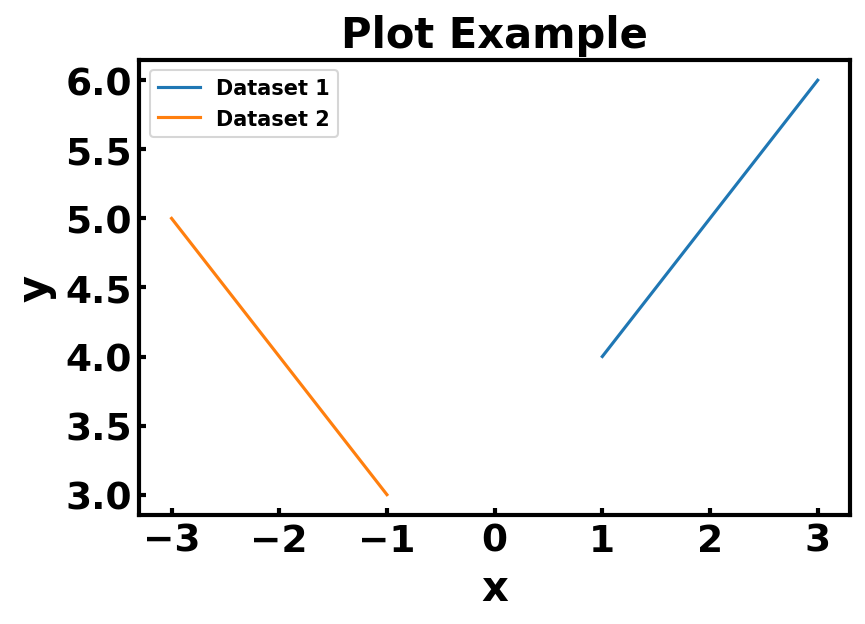

In [4]:
line = [
    {'x': df_plot['x1'].values, 'y': df_plot['y1'].values, 'label': 'Dataset 1'},
    {'x': df_plot['x2'].values, 'y': df_plot['y2'].values, 'label': 'Dataset 2'},
]

mtlab.plot(line, dpiValue=150, title='Plot Example', xlabel='x', ylabel='y', saveFig=False)

## 3. `mtlab.moving_average` — Smoothing

Compare raw signal vs. smoothed versions with different window sizes.

In [5]:
df_fit = pd.read_csv('test_data/fitting.csv')
df_fit.head()

,Unnamed: 0,x,y
0,0,781.0,-0.000285
1,1,782.0,-0.000181
2,2,783.0,0.000094
3,3,784.5,-0.000711
4,4,785.5,-0.000363


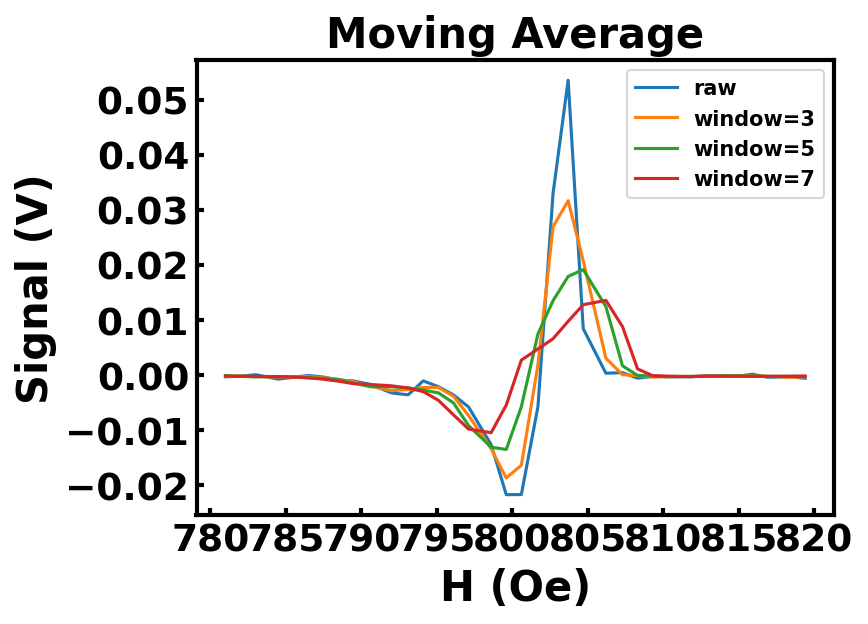

In [6]:
x_raw = df_fit['x'].values
y_raw = df_fit['y'].values

smooth_lines = [{'x': x_raw, 'y': y_raw, 'label': 'raw'}]

for w in [3, 5, 7]:
    y_sm = mtlab.moving_average(y_raw, w)
    smooth_lines.append({'x': x_raw, 'y': y_sm, 'label': f'window={w}'})

mtlab.plot(smooth_lines, dpiValue=150, title='Moving Average', xlabel='H (Oe)', ylabel='Signal (V)', saveFig=False)

## 4. `mtlab.diff_fitting` — Derivative Lorentzian fit

The ST-FMR signal is modelled as the derivative of a Lorentzian:

$$f(H) = \frac{A T^2 (2H_0 - 2H)}{(T^2 + (H_0 - H)^2)^2} - \frac{2BT(H_0-H)(2H_0-2H)}{(T^2+(H_0-H)^2)^2} - \frac{2BT}{T^2+(H_0-H)^2}$$

where $T$ is linewidth, $H_0$ is resonance field, $A$ (symmetric) and $B$ (antisymmetric) are amplitudes.

In [7]:
x = df_fit['x'].values
y = df_fit['y'].values

# Set initial guesses
params = lmfit.Parameters()
params.add('A', value=-0.08)
params.add('B', value=0.1)
params.add('T', value=5)
params.add('H', value=800)

out = mtlab.diff_fitting(params, x, y)

print(lmfit.fit_report(out))

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 75
    # data points      = 36
    # variables        = 4
    chi-square         = 2.8891e-04
    reduced chi-square = 9.0284e-06
    Akaike info crit   = -414.384936
    Bayesian info crit = -408.050860
[[Variables]]
    A: -0.06435859 +/- 0.00833932 (12.96%) (init = -0.08)
    B: -0.04320859 +/- 0.00340924 (7.89%) (init = 0.1)
    T:  1.79753777 +/- 0.10069331 (5.60%) (init = 5)
    H:  802.905793 +/- 0.08487810 (0.01%) (init = 800)
[[Correlations]] (unreported correlations are < 0.100)
    C(A, H) = +0.8010
    C(B, H) = -0.6688
    C(A, B) = -0.4681
    C(A, T) = -0.3177
    C(B, T) = -0.2282
    C(T, H) = -0.1396


H_res = 802.91 Oe
Linewidth T = 1.80 Oe
A = -0.0644
B = -0.0432


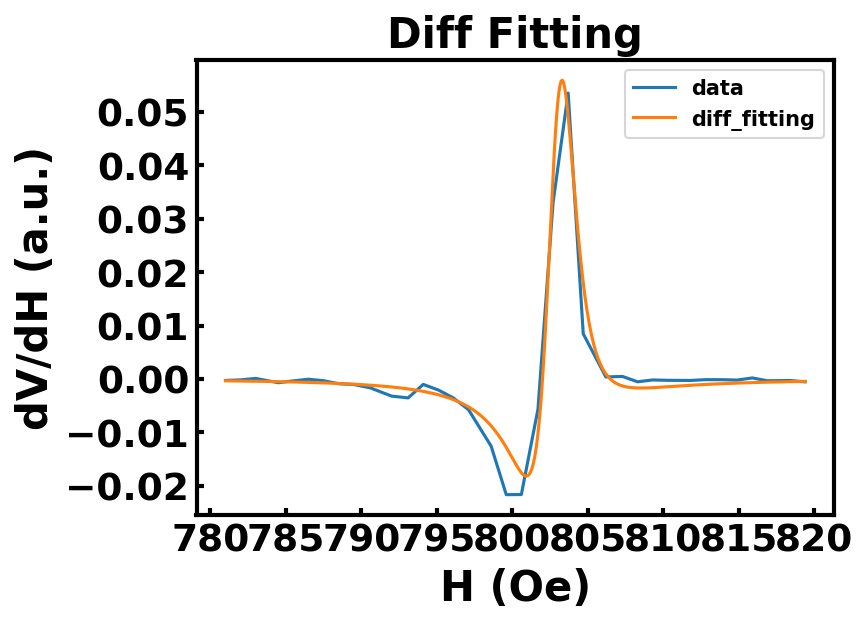

In [8]:
x_dense = np.linspace(x.min(), x.max(), 500)
y_fit = mtlab.diff_fit_data(out.params, x_dense)

result_lines = [
    {'x': x, 'y': y, 'label': 'data'},
    {'x': x_dense, 'y': y_fit, 'label': 'diff_fitting'},
]

mtlab.plot(result_lines, dpiValue=150, title='Diff Fitting', xlabel='H (Oe)', ylabel='dV/dH (a.u.)', saveFig=False)

# Print fitted parameters
print(f"H_res = {out.params['H'].value:.2f} Oe")
print(f"Linewidth T = {out.params['T'].value:.2f} Oe")
print(f"A = {out.params['A'].value:.4f}")
print(f"B = {out.params['B'].value:.4f}")

## 5. `mtlab.residual` / `mtlab.fit_data` — Symmetric + Antisymmetric Lorentzian

This model fits a direct FMR signal (not the derivative):

$$V(H) = \frac{S \cdot T^2}{(H - H_{\rm FMR})^2 + T^2} + \frac{A \cdot T(H - H_{\rm FMR})}{(H - H_{\rm FMR})^2 + T^2} + c$$

We use synthetic data here since `fitting.csv` is a derivative-shaped signal.

In [9]:
# Generate synthetic Lorentzian data with noise
np.random.seed(42)
x_syn = np.linspace(750, 850, 200)
S_true, A_true, T_true, Hfmr_true, c_true = 0.08, 0.03, 8.0, 800.0, 0.002

p_true = lmfit.Parameters()
p_true.add('S', value=S_true); p_true.add('A', value=A_true)
p_true.add('T', value=T_true); p_true.add('Hfmr', value=Hfmr_true)
p_true.add('c', value=c_true)
y_syn = mtlab.fit_data(p_true, x_syn) + np.random.normal(0, 0.002, len(x_syn))

params2 = lmfit.Parameters()
params2.add('S',    value=0.05)
params2.add('A',    value=0.01)
params2.add('T',    value=10)
params2.add('c',    value=0)
params2.add('Hfmr', value=795)

out2 = lmfit.minimize(mtlab.residual, params2, args=(x_syn, y_syn))
print(lmfit.fit_report(out2))

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 44
    # data points      = 200
    # variables        = 5
    chi-square         = 6.8243e-04
    reduced chi-square = 3.4996e-06
    Akaike info crit   = -2507.63355
    Bayesian info crit = -2491.14196
[[Variables]]
    S:     0.07982315 +/- 5.6877e-04 (0.71%) (init = 0.05)
    A:     0.03001734 +/- 6.7784e-04 (2.26%) (init = 0.01)
    T:     8.10403019 +/- 0.09269460 (1.14%) (init = 10)
    c:     0.00175382 +/- 2.2798e-04 (13.00%) (init = 0)
    Hfmr:  800.032792 +/- 0.08262447 (0.01%) (init = 795)
[[Correlations]] (unreported correlations are < 0.100)
    C(A, Hfmr) = -0.7661
    C(T, c)    = -0.6238
    C(S, Hfmr) = +0.3807
    C(S, T)    = -0.3215
    C(A, c)    = +0.3165
    C(S, c)    = -0.2945
    C(A, T)    = -0.2664
    C(c, Hfmr) = -0.2635
    C(S, A)    = -0.2229
    C(T, Hfmr) = +0.1003


H_FMR = 800.03 Oe  (true: 800.0)
Linewidth T = 8.10 Oe  (true: 8.0)
S = 0.0798  (true: 0.08)


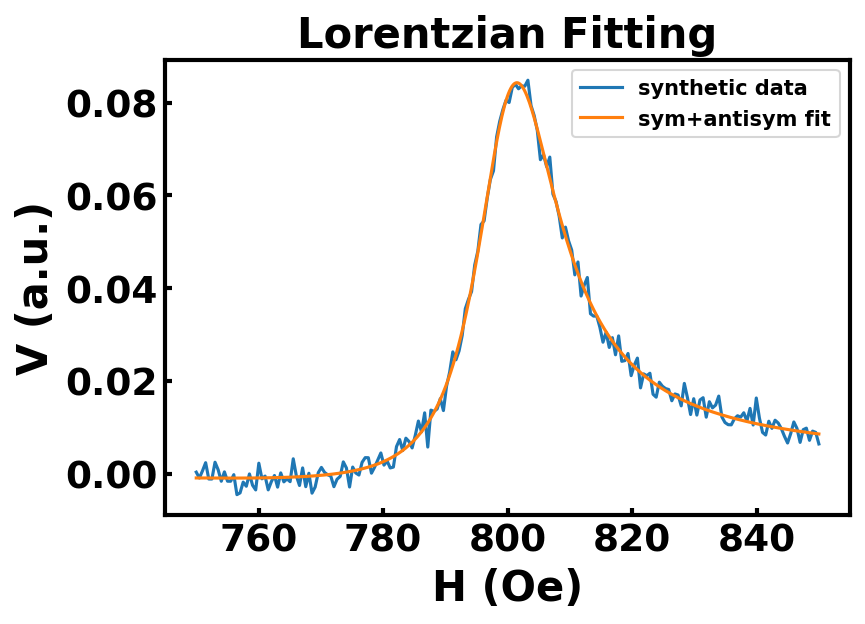

In [10]:
x_dense_syn = np.linspace(x_syn.min(), x_syn.max(), 500)
y_fit2 = mtlab.fit_data(out2.params, x_dense_syn)

result2_lines = [
    {'x': x_syn, 'y': y_syn, 'label': 'synthetic data'},
    {'x': x_dense_syn, 'y': y_fit2, 'label': 'sym+antisym fit'},
]

mtlab.plot(result2_lines, dpiValue=150, title='Lorentzian Fitting', xlabel='H (Oe)', ylabel='V (a.u.)', saveFig=False)

print(f'H_FMR = {out2.params["Hfmr"].value:.2f} Oe  (true: {Hfmr_true})')
print(f'Linewidth T = {out2.params["T"].value:.2f} Oe  (true: {T_true})')
print(f'S = {out2.params["S"].value:.4f}  (true: {S_true})')

## 6. `mtlab.residual_kittel` / `mtlab.fit_data_kittel` — Kittel Dispersion

Fits the Kittel equation relating resonance frequency to applied field:

$$f = \frac{g\mu_B}{h}\sqrt{H(H + M_s)} \times 10^{-13}$$

Extracts the g-factor and effective saturation magnetization $M_s$.

In [11]:
np.random.seed(0)
H_points = np.linspace(300, 3500, 15)
g_true, M_true = 2.05, 8000.0

p_true = lmfit.Parameters()
p_true.add('g', value=g_true); p_true.add('M', value=M_true)
f_points = mtlab.fit_data_kittel(p_true, H_points) + np.random.normal(0, 0.02, len(H_points))

params_k = lmfit.Parameters()
params_k.add('g', value=2.0,    min=1.5, max=3.0)
params_k.add('M', value=9000.0, min=1000, max=20000)

out_k = lmfit.minimize(mtlab.residual_kittel, params_k, args=(H_points, f_points))
print(lmfit.fit_report(out_k))

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 13
    # data points      = 15
    # variables        = 2
    chi-square         = 220.976797
    reduced chi-square = 16.9982152
    Akaike info crit   = 44.3501126
    Bayesian info crit = 45.7662130
[[Variables]]
    g:  2.04142960 +/- 0.00876203 (0.43%) (init = 2)
    M:  8104.60896 +/- 91.5976722 (1.13%) (init = 9000)
[[Correlations]] (unreported correlations are < 0.100)
    C(g, M) = -0.9974


g  = 2.0414  (true: 2.05)
Ms = 8104.6 Oe  (true: 8000.0)


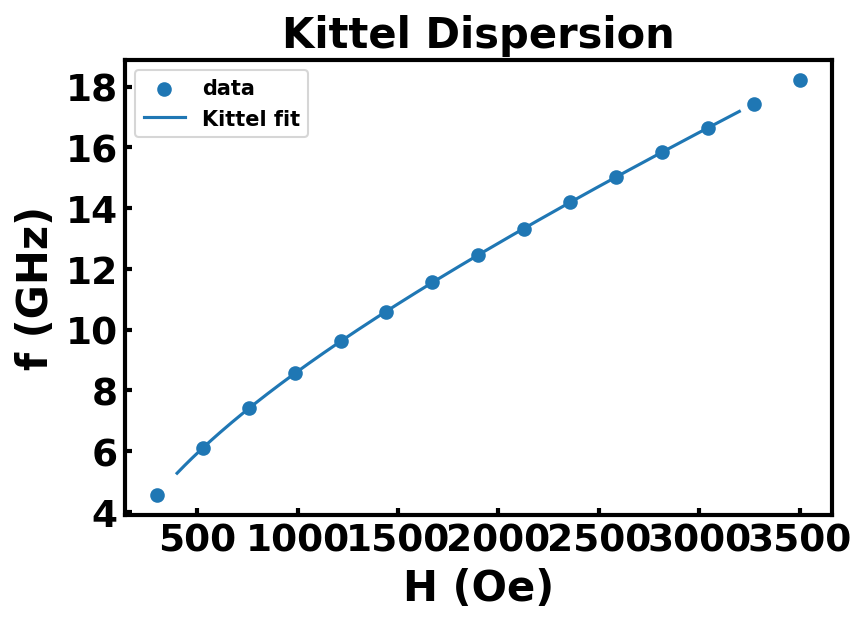

In [12]:
H_dense = np.linspace(400, 3200, 300)
f_fit = mtlab.fit_data_kittel(out_k.params, H_dense)

kittel_lines = [
    {'x': H_points, 'y': f_points, 'label': 'data', 'type': 'scatter'},
    {'x': H_dense,  'y': f_fit,    'label': 'Kittel fit'},
]
mtlab.plot(kittel_lines, dpiValue=150, title='Kittel Dispersion',
           xlabel='H (Oe)', ylabel='f (GHz)', saveFig=False)

print(f'g  = {out_k.params["g"].value:.4f}  (true: {g_true})')
print(f'Ms = {out_k.params["M"].value:.1f} Oe  (true: {M_true})')

## 7. `mtlab.residual_damping` / `mtlab.fit_data_damping` — Gilbert Damping

Fits the linear relationship between FMR linewidth $\Delta H$ and frequency:

$$\Delta H = \Delta H_0 + \frac{2\pi\alpha h}{g\mu_B} f \times 10^{16}$$

Extracts the Gilbert damping constant $\alpha$ and inhomogeneous broadening $\Delta H_0$.

In [13]:
np.random.seed(1)
f_points_d = mtlab.fit_data_kittel(p_true, H_points)
alpha_true, H0_true = 0.008, 15.0

p_true_d = lmfit.Parameters()
p_true_d.add('g', value=g_true); p_true_d.add('a', value=alpha_true); p_true_d.add('H0', value=H0_true)
dH_points = mtlab.fit_data_damping(p_true_d, f_points_d) + np.random.normal(0, 2, len(f_points_d))

params_d = lmfit.Parameters()
params_d.add('g',  value=2.0,   min=1.5, max=3.0)
params_d.add('a',  value=0.01,  min=0)
params_d.add('H0', value=10.0)

out_d = lmfit.minimize(mtlab.residual_damping, params_d, args=(f_points_d, dH_points))
print(lmfit.fit_report(out_d))

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 33
    # data points      = 15
    # variables        = 3
    chi-square         = 88.3423418
    reduced chi-square = 7.36186182
    Akaike info crit   = 32.5975397
    Bayesian info crit = 34.7216903
[[Variables]]
    g:   2.53739361 +/- 91564279.3 (3608595807.02%) (init = 2)
    a:   0.00989121 +/- 356811.792 (3607362723.25%) (init = 0.01)
    H0:  15.0789962 +/- 2.29623135 (15.23%) (init = 10)
[[Correlations]] (unreported correlations are < 0.100)
    C(g, a)  = +1.0000
    C(a, H0) = -0.3100
    C(g, H0) = -0.3100


α   = 0.0099  (true: 0.008)
ΔH0 = 15.08 Oe  (true: 15.0)


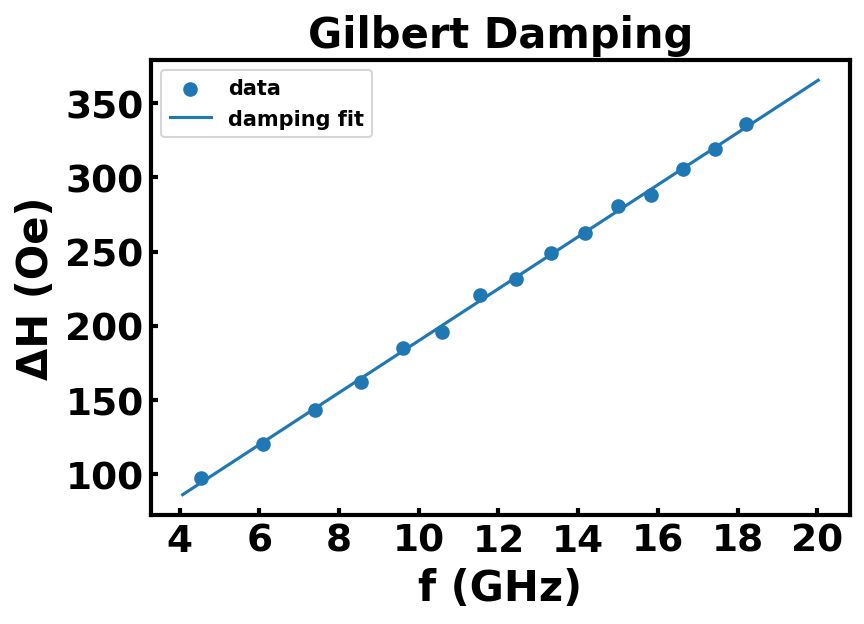

In [14]:
f_dense_d = np.linspace(f_points_d.min() * 0.9, f_points_d.max() * 1.1, 200)
dH_fit = mtlab.fit_data_damping(out_d.params, f_dense_d)

damp_lines = [
    {'x': f_points_d, 'y': dH_points, 'label': 'data', 'type': 'scatter'},
    {'x': f_dense_d,  'y': dH_fit,    'label': 'damping fit'},
]
mtlab.plot(damp_lines, dpiValue=150, title='Gilbert Damping',
           xlabel='f (GHz)', ylabel='ΔH (Oe)', saveFig=False)

print(f'α   = {out_d.params["a"].value:.4f}  (true: {alpha_true})')
print(f'ΔH0 = {out_d.params["H0"].value:.2f} Oe  (true: {H0_true})')